In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sitharthvarsan/churn-data/Retention.csv
/kaggle/input/datasets/sitharthvarsan/churn-data/BoB.xlsx


## 1. IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

## 2. LOAD DATA

In [3]:
bob_df = pd.read_excel("/kaggle/input/datasets/sitharthvarsan/churn-data/BoB.xlsx")
ret_df = pd.read_csv("/kaggle/input/datasets/sitharthvarsan/churn-data/Retention.csv", encoding='latin1')

## 3. INITIAL DATA CHECKING

In [4]:
print("BoB Shape:", bob_df.shape)
print("Retention Shape:", ret_df.shape)

bob_df.head()
ret_df.head()

BoB Shape: (376803, 26)
Retention Shape: (85411, 29)


,Case ID,Case Title,Country,Pull VAN,New VAN,VAN,Number of Contracts,Machines,Branch,Customer Account Number,...,Number of OverdueServices,CompanySize,Customer Tier,Case Origin,Case Creation Date,Resolved Time,Registered Time,Resolved Date,Registered Date,Expected Pull Date
0,CAS-32058-P6H2Z7,Service Claim,United Kingdom,0.0,0.0,0.00,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,Internal Email,26-09-2025 16:05,NaN,17:00:00,NaN,23-07-2025,29-Jun-26
1,CAS-32054-V6L5K1,Service Claim,United Kingdom,0.0,0.0,423.00,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,Internal Email,26-09-2025 16:02,NaN,17:00:00,NaN,23-07-2025,16-May-26
2,CAS-32054-V6L5K1,Service Claim,United Kingdom,0.0,0.0,352.50,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,Internal Email,26-09-2025 16:02,NaN,17:00:00,NaN,23-07-2025,16-May-26
3,CAS-42090-M1V1V7,SRF - Machine not used,United Kingdom,0.0,0.0,1769.76,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,Internal Email,31-10-2025 14:50,NaN,16:50:38,NaN,31-10-2025,30-Jan-27
4,CAS-42090-M1V1V7,SRF - Machine not used,United Kingdom,0.0,0.0,1474.80,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,Internal Email,31-10-2025 14:50,NaN,16:50:38,NaN,31-10-2025,30-Jan-27


#### Data types

In [5]:
bob_df.info()
ret_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376803 entries, 0 to 376802
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   account_number        376784 non-null  object        
 1   company_sizing        374120 non-null  object        
 2   postal_code           376782 non-null  object        
 3   branch                376784 non-null  object        
 4   vat_number            376388 non-null  object        
 5   agreement_number      376784 non-null  object        
 6   agreement_start_date  376784 non-null  datetime64[ns]
 7   agreement_end_date    376784 non-null  datetime64[ns]
 8   renewal_type          376784 non-null  object        
 9   agreement_type        376784 non-null  object        
 10  line_of_business      376784 non-null  object        
 11  system_status         376784 non-null  object        
 12  product_bob           376793 non-null  float64       
 13 

####  Missing values

In [6]:
print("BoB Missing:\n", bob_df.isnull().sum())
print("Retention Missing:\n", ret_df.isnull().sum())

BoB Missing:
 account_number              19
company_sizing            2683
postal_code                 21
branch                      19
vat_number                 415
agreement_number            19
agreement_start_date        19
agreement_end_date          19
renewal_type                19
agreement_type              19
line_of_business            19
system_status               19
product_bob                 10
fee_bob                     10
total_bob                   10
is_bob                      19
bpg                       3443
msdyn_product_number      2264
product_name              2264
service_interval         72020
unit_amount               3294
billing_interval         17741
billing_period           17741
machine                 196468
machine_variant         196459
chemistry               238755
dtype: int64
Retention Missing:
 Case ID                          0
Case Title                       0
Country                          0
Pull VAN                         0
New VAN

##### Duplicate check

In [7]:
print("BoB duplicates:", bob_df.duplicated().sum())
print("Retention duplicates:", ret_df.duplicated().sum())

BoB duplicates: 177814
Retention duplicates: 2944


## 4. HYPOTHESIS

H1: Customers with lower remaining_days (contracts near expiry) are more likely to churn.

H2: Customers with fewer agreements (low agreement_count) have higher risk of full churn.

H3: Customers with higher resolution time (resolved_time_sec) are more likely to churn due to poor service experience.

H4: Customers with lower revenue per agreement are more likely to churn, indicating lower perceived value.

H5: Customers with shorter tenure (tenure_days) are more likely to churn compared to long-term customers.

## 5. CLEAN BoB DATA

#### Select useful columns

In [8]:
bob_df = bob_df[
    [
        'account_number',
        'company_sizing',
        'agreement_number',
        'agreement_start_date',
        'agreement_end_date',
        'total_bob',
        'unit_amount',
        'line_of_business',
        'service_interval',
        'msdyn_product_number'
    ]
]

#### Remove duplicates

In [9]:
print("Before BoB duplicates:", bob_df.duplicated().sum())
bob_df = bob_df.drop_duplicates()
print("After BoB duplicates:", bob_df.duplicated().sum())


Before BoB duplicates: 205547
After BoB duplicates: 0


#### Handle missing values

In [10]:
# numerical
bob_df['service_interval'] = bob_df['service_interval'].fillna(bob_df['service_interval'].median())
bob_df['unit_amount'] = bob_df['unit_amount'].fillna(bob_df['unit_amount'].median())
# categorical
bob_df['company_sizing'] = bob_df['company_sizing'].fillna('Unknown')
bob_df['line_of_business'] = bob_df['line_of_business'].fillna('Unknown')

#### Drop useless column

In [11]:
bob_df.drop(columns=['msdyn_product_number'], inplace=True)

## 6. CLEAN RETENTION DATA

#### Keep required columns

In [12]:
ret_df = ret_df[
    [
        'Customer Account Number',
        'Resolved Time',
        'Resolution Status'
    ]
]

#### Filter valid outcomes

In [13]:
ret_df = ret_df[ret_df['Resolution Status'].isin([
    'Customer Lost',
    'Customer Saved',
    'Converted to Cancellation'
])]

#### Create target

In [14]:
ret_df['churn'] = ret_df['Resolution Status'].map({
    'Customer Lost': 1,
    'Converted to Cancellation': 1,
    'Customer Saved': 0
})

#### Validate target

In [15]:
print(ret_df['churn'].value_counts())

churn
0    37477
1    34406
Name: count, dtype: int64


#### Resolved Time Processing

In [16]:
ret_df['Resolved Time'] = pd.to_timedelta(ret_df['Resolved Time'],errors='coerce')
ret_df['resolved_time_sec'] = ret_df['Resolved Time'].dt.total_seconds()
median_time = ret_df['resolved_time_sec'].median()

ret_df['resolved_time_sec'] = ret_df['resolved_time_sec'].fillna(median_time)
ret_df['resolved_time_hours'] = ret_df['resolved_time_sec'] / 3600

ret_df = ret_df.drop(columns=['Resolved Time'])

# ===============================
# VALIDATION
# ===============================

print("Null Values:\n", ret_df.isnull().sum())
print("\nSample Data:\n", ret_df.head())

Null Values:
 Customer Account Number    3270
Resolution Status             0
churn                         0
resolved_time_sec             0
resolved_time_hours           0
dtype: int64

Sample Data:
       Customer Account Number Resolution Status  churn  resolved_time_sec  \
13000       UK02-CGBA021060-L    Customer Saved      0            44283.0   
13001       UK02-CGBA021060-L    Customer Saved      0            44431.0   
13002       UK02-CGBA021060-L    Customer Saved      0            44431.0   
13003       UK02-CGBA021060-L    Customer Saved      0            65017.0   
13004       UK02-CGBA021060-L    Customer Saved      0            65017.0   

       resolved_time_hours  
13000            12.300833  
13001            12.341944  
13002            12.341944  
13003            18.060278  
13004            18.060278  


## 7. AGGREGATE RETENTION

In [17]:
ret_customer = ret_df.groupby('Customer Account Number').agg({
    'churn': 'max',
    'resolved_time_sec': 'mean'
}).reset_index()

## 8. MERGE DATASETS

In [18]:
final_df = pd.merge(
    bob_df,
    ret_customer,
    left_on='account_number',
    right_on='Customer Account Number',
    how='inner'
)

final_df.drop(columns=['Customer Account Number'], inplace=True)

## 9. POST-MERGE VALIDATION

In [19]:
print("Final Shape:", final_df.shape)

final_df.isnull().sum()
final_df.duplicated().sum()

Final Shape: (30424, 11)


np.int64(1252)

## 10. EDA

#### Target distribution

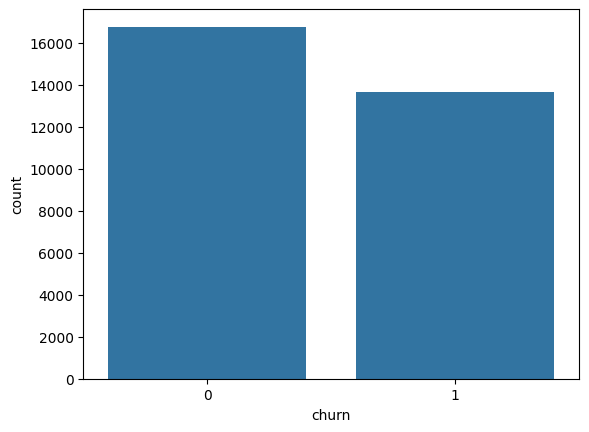

In [19]:
sns.countplot(x='churn', data=final_df)
plt.show()

#### Numerical vs churn

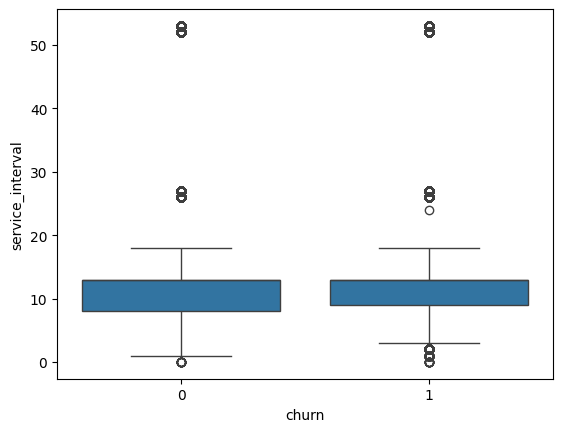

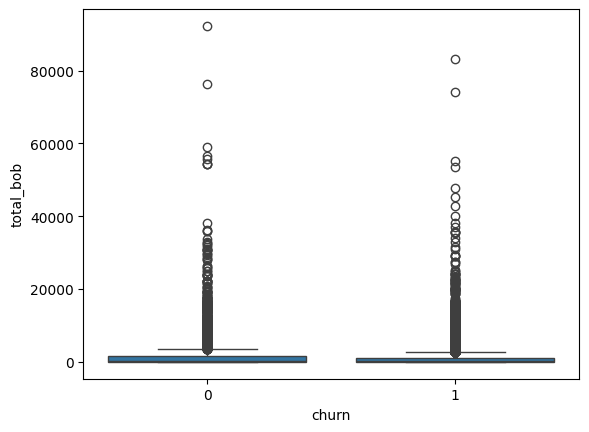

In [20]:
sns.boxplot(data=final_df, x='churn', y='service_interval')
plt.show()

sns.boxplot(data=final_df, x='churn', y='total_bob')
plt.show()

#### Categorical vs churn

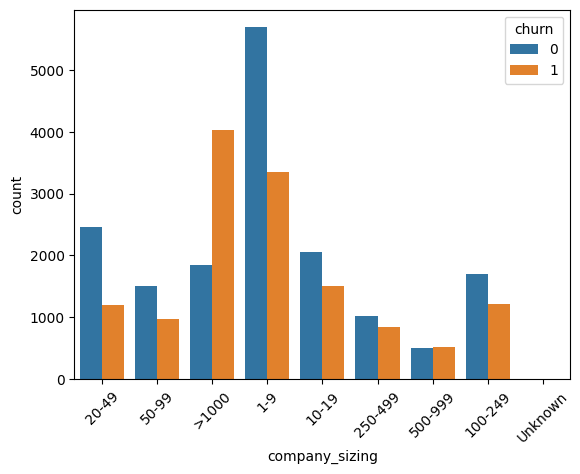

In [21]:
sns.countplot(data=final_df, x='company_sizing', hue='churn')
plt.xticks(rotation=45)
plt.show()

#### Checking skewness

unit_amount         9.432342
total_bob           8.217866
service_interval    2.143886
churn               0.207134
dtype: float64


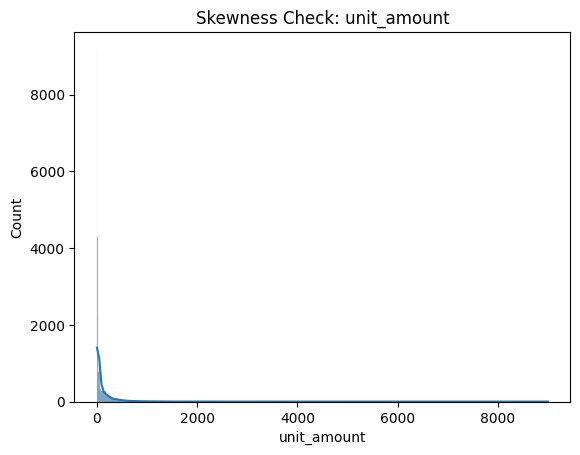

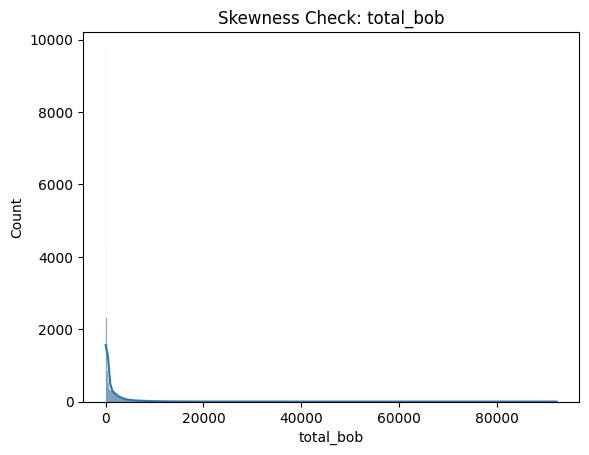

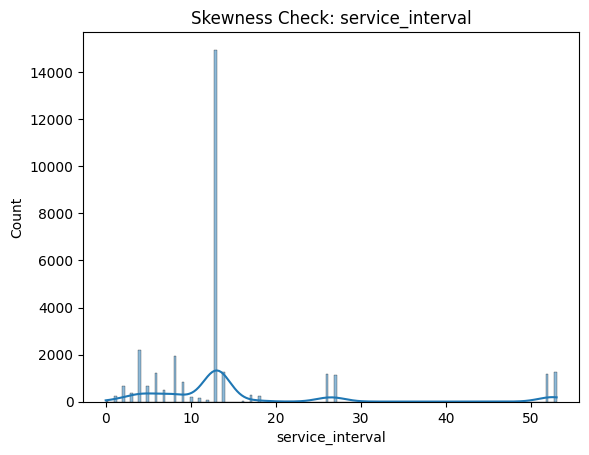

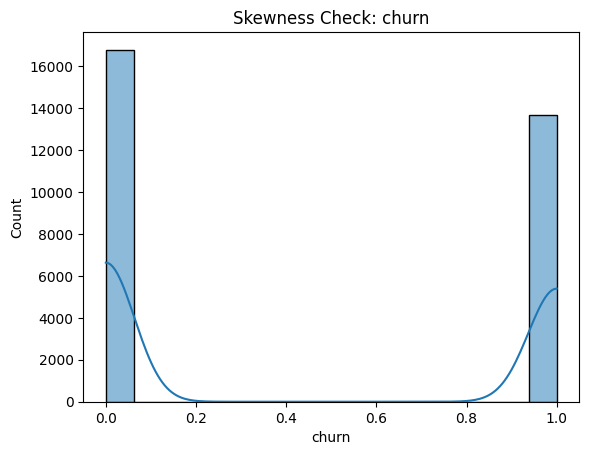

In [22]:
skewness = final_df.skew(numeric_only=True).sort_values(ascending=False)
print(skewness)

top_skewed = skewness.head(5).index

for col in top_skewed:
    plt.figure()
    sns.histplot(final_df[col], kde=True)
    plt.title(f"Skewness Check: {col}")
    plt.show()

#### Checking Outliers

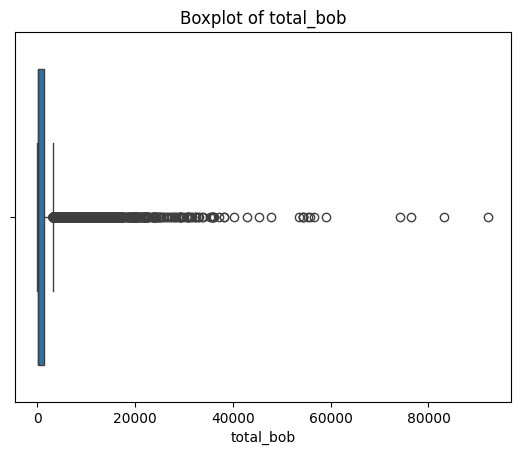

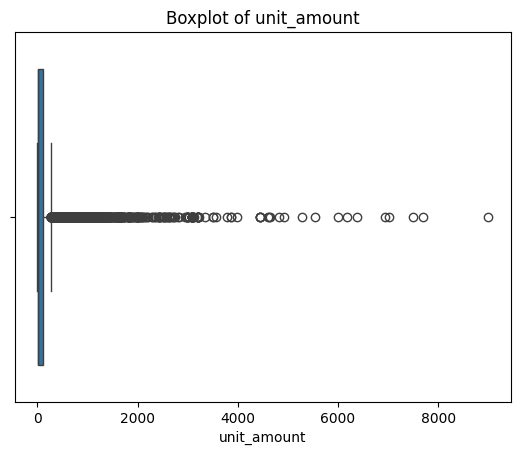

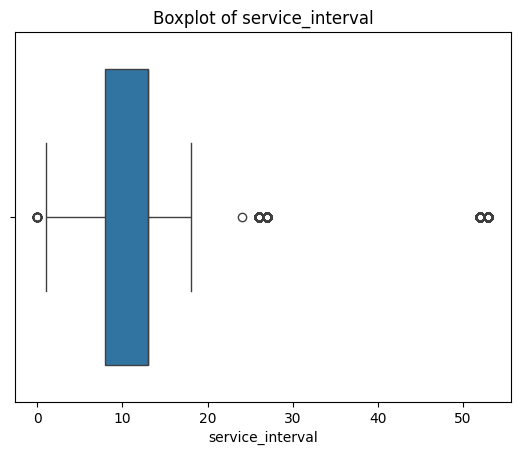

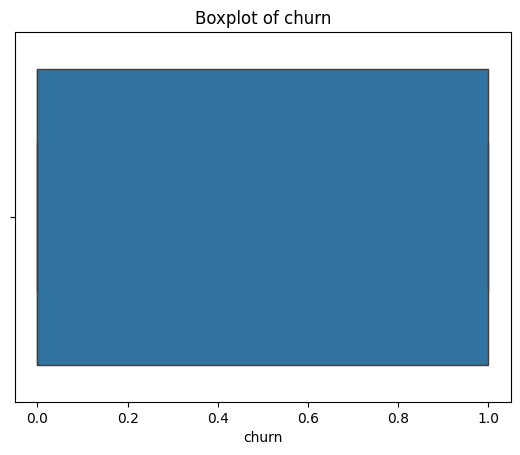

service_interval    4755
unit_amount         3395
total_bob           3265
churn                  0
dtype: int64


In [23]:
num_cols = final_df.select_dtypes(include=['int64', 'float64']).columns
# Boxplot for all numerical columns
for col in num_cols:
    plt.figure()
    sns.boxplot(x=final_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# Detect Outliers (IQR method)
outlier_summary = {}
for col in num_cols:
    Q1 = final_df[col].quantile(0.25)
    Q3 = final_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = final_df[(final_df[col] < lower) | (final_df[col] > upper)]
    outlier_summary[col] = len(outliers)
print(pd.Series(outlier_summary).sort_values(ascending=False))

## 11. FEATURE ENGINEERING

#### Apply Log tranformation to total_bob & unit_amount

In [20]:
final_df['total_bob'] = np.log1p(final_df['total_bob'])
final_df['unit_amount'] = np.log1p(final_df['unit_amount'])

#### Company_size

In [21]:
# ===============================
# CLEAN + FIX + ENCODE COMPANY SIZE
# ===============================

# Step 1: Standardize text
final_df['company_sizing'] = final_df['company_sizing'].astype(str).str.strip()

# Step 2: Define valid values
valid_sizes = [
    '1-9', '10-19', '20-49', '50-99',
    '100-249', '250-499', '500-999', '>1000'
]

# Step 3: Fix corrupted values (Excel issues)
def fix_company_size(val):
    val = str(val).strip()

    # If already valid
    if val in valid_sizes:
        return val

    # Excel converted "1-9" → "01-Sep"
    if val.startswith('01-') or val.startswith('1-'):
        return '1-9'

    # Excel converted "10-19" → "Oct-19"
    if 'Oct' in val or val.startswith('10-'):
        return '10-19'

    # Add more rules if needed
    return 'Unknown'

# Step 4: Apply cleaning
final_df['company_sizing'] = final_df['company_sizing'].apply(fix_company_size)

# Step 5: Remove unknown values
final_df = final_df[final_df['company_sizing'] != 'Unknown']

# Step 6: Convert to ordinal numeric scale
size_mapping = {
    '1-9': 1,
    '10-19': 2,
    '20-49': 3,
    '50-99': 4,
    '100-249': 5,
    '250-499': 6,
    '500-999': 7,
    '>1000': 8
}

final_df['company_sizing'] = final_df['company_sizing'].map(size_mapping)

# Step 7: Validation
print("Missing values:", final_df['company_sizing'].isnull().sum())
print(final_df['company_sizing'].value_counts())

# Step 8: Reset index
final_df = final_df.reset_index(drop=True)

Missing values: 0
company_sizing
1    9042
8    5867
3    3665
2    3558
5    2908
4    2488
6    1876
7    1012
Name: count, dtype: int64


In [28]:
final_df.head()

,account_number,company_sizing,agreement_number,agreement_start_date,agreement_end_date,total_bob,unit_amount,line_of_business,service_interval,churn
0,UK02-CGBA124601-L,3,GBC4000950-Auto waste,2022-06-24,2026-06-23,11.432188,8.947400,Auto waste,0.0,0
1,UK02-CGBA034502-L,4,GBC3028394-Chemistry,2024-11-04,2025-11-03,11.329098,8.844323,Chemistry,1.0,1
2,UK02-CGBA110426-L,8,GBC3034379-Machine Services-306741,2022-05-31,2026-05-30,11.244166,8.759403,Machine Services,2.0,0
3,UK02-CGBA203138-L,1,GBC4006420-Machine Services-307632,2022-07-01,2026-06-30,10.987517,8.502796,Machine Services,2.0,0
4,UK02-CGBA000084-L,8,GBC4017987-Machine Services-325528,2024-06-24,2027-06-23,10.928720,8.444012,Machine Services,1.0,0


#### Convert dates

In [22]:
final_df['agreement_start_date'] = pd.to_datetime(final_df['agreement_start_date'])
final_df['agreement_end_date'] = pd.to_datetime(final_df['agreement_end_date'])

#### Create time features

In [23]:
today = pd.to_datetime("today")

final_df['tenure_days'] = (today - final_df['agreement_start_date']).dt.days
final_df['remaining_days'] = (final_df['agreement_end_date'] - today).dt.days

#### Creating near_expiry and revenue_per_day

In [25]:
# Near expiry risk
final_df['near_expiry'] = np.where(final_df['remaining_days'] < 30, 1, 0)

# Revenue efficiency
final_df['revenue_per_day'] = final_df['total_bob'] / (final_df['tenure_days'] + 1)

#### Drop raw date columns

In [26]:
final_df.drop(columns=['agreement_start_date', 'agreement_end_date'], inplace=True)

#### Remove exact duplicates

In [27]:
final_df = final_df.drop_duplicates().reset_index(drop=True)

#### Fix negative remaining_days

In [28]:
final_df['remaining_days'] = final_df['remaining_days'].clip(lower=0)
final_df = final_df.reset_index(drop=True)

#### Creating agreement_count

In [29]:
print(final_df[['account_number', 'agreement_number']].isnull().sum())
# Dropping invalid rows
final_df = final_df.dropna(subset=['account_number', 'agreement_number'])

final_df['agreement_number'] = final_df['agreement_number'].astype(str).str.strip()

# Remove exact duplicate rows
final_df = final_df.drop_duplicates().reset_index(drop=True)

# Creating agreement_count
final_df['agreement_count'] = final_df.groupby('account_number')['agreement_number'].transform('nunique')

# Validating
print(final_df[['account_number', 'agreement_number', 'agreement_count']].head())
print("Any zero agreement_count:",
      (final_df['agreement_count'] == 0).sum())

account_number      0
agreement_number    0
dtype: int64
      account_number                    agreement_number  agreement_count
0  UK02-CGBA124601-L               GBC4000950-Auto waste                3
1  UK02-CGBA034502-L                GBC3028394-Chemistry                3
2  UK02-CGBA110426-L  GBC3034379-Machine Services-306741                1
3  UK02-CGBA203138-L  GBC4006420-Machine Services-307632                8
4  UK02-CGBA000084-L  GBC4017987-Machine Services-325528               48
Any zero agreement_count: 0


#### Aggregate to customer level

In [32]:
final_df = final_df.groupby('account_number').agg({
    
    # Categorical
    'company_sizing': 'first',
    'line_of_business': 'first',
    
    # Financial
    'total_bob': 'sum',
    
    # Service behavior
    'service_interval': 'mean',
    
    # Contract lifecycle
    'tenure_days': 'max',
    'remaining_days': 'min',
    
    # Agreement structure
    'agreement_count': 'max',
    
    # 🔥 NEW (Retention signal)
    'resolved_time_sec': 'mean',
    
    # Target
    'churn': 'max'

}).reset_index()

#### Creating Revenue per agreement

In [39]:
final_df['agreement_count'] = final_df['agreement_count'].replace(0, 1)

# Step 2: Revenue per agreement (CORRECT FORMULA)
final_df['revenue_per_agreement'] = (
    final_df['total_bob'] / final_df['agreement_count']
)

## 12. STATISTICAL HYPOTHESIS TESTING

#### H1: Customers with lower remaining_days (contracts near expiry) are more likely to churn.

In [35]:
# H1: Customers with lower remaining_days are more likely to churn
from scipy.stats import mannwhitneyu
feature = 'remaining_days'

churn_0 = final_df[final_df['churn'] == 0][feature].dropna()
churn_1 = final_df[final_df['churn'] == 1][feature].dropna()

stat, p_value = mannwhitneyu(churn_0, churn_1)

print("H1: remaining_days")
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant")
else:
    print("Not Significant")

H1: remaining_days
P-value: 0.03901453048367556
Significant


#### H2: Customers with fewer agreements (low agreement_count) have higher risk of full churn.

In [36]:
# H2: Customers with fewer agreements have higher churn risk

feature = 'agreement_count'

churn_0 = final_df[final_df['churn'] == 0][feature].dropna()
churn_1 = final_df[final_df['churn'] == 1][feature].dropna()

stat, p_value = mannwhitneyu(churn_0, churn_1)

print("H2: agreement_count")
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant")
else:
    print("Not Significant")

H2: agreement_count
P-value: 0.08370543631253294
Not Significant


#### H3: Customers with higher resolution time (resolved_time_sec) are more likely to churn due to poor service experience.

In [37]:
# H3: Higher resolution time leads to higher churn

feature = 'resolved_time_sec'

churn_0 = final_df[final_df['churn'] == 0][feature].dropna()
churn_1 = final_df[final_df['churn'] == 1][feature].dropna()

stat, p_value = mannwhitneyu(churn_0, churn_1)

print("H3: resolved_time_sec")
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant")
else:
    print("Not Significant")

H3: resolved_time_sec
P-value: 1.2005965190388136e-229
Significant


#### H4: Customers with lower revenue per agreement are more likely to churn, indicating lower perceived value.

In [40]:
# H4: Lower revenue per agreement → higher churn

feature = 'revenue_per_agreement'

churn_0 = final_df[final_df['churn'] == 0][feature].dropna()
churn_1 = final_df[final_df['churn'] == 1][feature].dropna()

stat, p_value = mannwhitneyu(churn_0, churn_1)

print("H4: revenue_per_agreement")
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant")
else:
    print("Not Significant")

H4: revenue_per_agreement
P-value: 0.023148465067729017
Significant


#### H5: Customers with shorter tenure (tenure_days) are more likely to churn compared to long-term customers.

In [41]:
# H5: Shorter tenure → higher churn

feature = 'tenure_days'

churn_0 = final_df[final_df['churn'] == 0][feature].dropna()
churn_1 = final_df[final_df['churn'] == 1][feature].dropna()

stat, p_value = mannwhitneyu(churn_0, churn_1)

print("H5: tenure_days")
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant")
else:
    print("Not Significant")

H5: tenure_days
P-value: 0.0009873410456401994
Significant


#### Hypothesis Summary Table

In [44]:
from scipy import stats

results = []

# -------------------------------
# Numerical Hypothesis Test
# -------------------------------
def mann_test(feature, name):
    g0 = final_df[final_df['churn'] == 0][feature].dropna()
    g1 = final_df[final_df['churn'] == 1][feature].dropna()
    
    stat, p = stats.mannwhitneyu(g0, g1)
    
    mean_0 = g0.mean()
    mean_1 = g1.mean()
    
    # Interpretation logic
    if p < 0.05:
        if mean_1 > mean_0:
            insight = "Higher value → Higher churn"
        else:
            insight = "Lower value → Higher churn"
        decision = "Accepted"
    else:
        insight = "No strong relation"
        decision = "Rejected"
    
    results.append([
        name,
        round(mean_0, 2),
        round(mean_1, 2),
        p,
        decision,
        insight
    ])


# -------------------------------
# RUN UPDATED HYPOTHESES
# -------------------------------

# H1
mann_test('remaining_days', 'H1: Remaining Days')

# H2
mann_test('agreement_count', 'H2: Agreement Count')

# H3
mann_test('resolved_time_sec', 'H3: Resolution Time')

# H4
mann_test('revenue_per_agreement', 'H4: Revenue per Agreement')

# H5
mann_test('tenure_days', 'H5: Tenure Days')


# -------------------------------
# SUMMARY TABLE
# -------------------------------

hypothesis_results = pd.DataFrame(
    results,
    columns=[
        'Hypothesis',
        'Mean_Non_Churn',
        'Mean_Churn',
        'p-value',
        'Decision',
        'Insight'
    ]
)

print(hypothesis_results)

                  Hypothesis  Mean_Non_Churn  Mean_Churn        p-value  \
0         H1: Remaining Days          114.16       97.85   3.901453e-02   
1        H2: Agreement Count            2.34        3.10   8.370544e-02   
2        H3: Resolution Time        46123.75    29821.76  1.200597e-229   
3  H4: Revenue per Agreement           12.30       12.01   2.314847e-02   
4            H5: Tenure Days         1646.63     1513.33   9.873410e-04   

   Decision                     Insight  
0  Accepted  Lower value → Higher churn  
1  Rejected          No strong relation  
2  Accepted  Lower value → Higher churn  
3  Accepted  Lower value → Higher churn  
4  Accepted  Lower value → Higher churn  


## 13. FEATURE SELECTION

In [46]:
duplicates = final_df[final_df.duplicated(keep=False)] \
    .sort_values('account_number')
print("Duplicate Rows:\n", duplicates.head(20))
final_df = final_df.drop_duplicates().reset_index(drop=True)

final_df = final_df[
    [
        'company_sizing',
        'total_bob',
        'service_interval',
        'tenure_days',
        'remaining_days',
        'agreement_count',
        'resolved_time_sec',
        'revenue_per_agreement',
        'churn'
    ]
]

# VALIDATION
print("Shape:", final_df.shape)
print("\nNull Values:\n", final_df.isnull().sum())
print("\nDuplicate Rows:", final_df.duplicated().sum())
print("\nSample Data:\n", final_df.head())

Duplicate Rows:
 Empty DataFrame
Columns: [account_number, company_sizing, line_of_business, total_bob, service_interval, tenure_days, remaining_days, agreement_count, resolved_time_sec, churn, revenue_per_agreement]
Index: []
Shape: (4850, 9)

Null Values:
 company_sizing           0
total_bob                0
service_interval         0
tenure_days              0
remaining_days           0
agreement_count          0
resolved_time_sec        0
revenue_per_agreement    0
churn                    0
dtype: int64

Duplicate Rows: 6

Sample Data:
    company_sizing   total_bob  service_interval  tenure_days  remaining_days  \
0               7   60.248606          9.333333         3388               0   
1               5   35.596662         10.375000          380             714   
2               8  542.139141         10.989691         3133               0   
3               3   66.668408         19.928571         3502               0   
4               8  527.432369         15.725100    

## 14. Business Interpretation (Churn Type)

In [47]:
business_df = final_df.copy()

business_df['churn_type'] = 'No Churn'

business_df.loc[
    (business_df['churn'] == 1) & (business_df['agreement_count'] > 1),
    'churn_type'
] = 'Partial Churn'

business_df.loc[
    (business_df['churn'] == 1) & (business_df['agreement_count'] == 1),
    'churn_type'
] = 'Full Churn'

print(business_df['churn_type'].value_counts())

churn_type
No Churn         2980
Partial Churn    1162
Full Churn        708
Name: count, dtype: int64


## 15. SAVE

In [53]:
final_df.to_csv("final_data.csv", index=False, quoting=1)

## 16. MODELING

#### 16.1: Define Features & Target

In [54]:
X = final_df.drop(columns=['churn'], errors='ignore')
y = final_df['churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4850, 14)
y shape: (4850,)


#### 16.2 Train-Test Split

We split the dataset into training and testing sets to evaluate model performance on unseen data.

In [55]:
from sklearn.model_selection import train_test_split

X = final_df.drop(columns=['churn'])
y = final_df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### 16.3 Encoding Categorical Variables

We convert categorical variables into numerical format using one-hot encoding.

In [56]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# STEP 3: Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

#### 16.4 Feature Scaling

We standardize numerical features so that all features contribute equally to the model.

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

#### 16.5 Baseline Model: Logistic Regression

We use Logistic Regression as a baseline to compare performance with advanced models.

In [58]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

#### 16.6 Random Forest Model

Random Forest captures non-linear relationships and interactions between features.

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

#### 16.7 XGBoost with Hyperparameter Tuning

We apply RandomizedSearchCV to optimize model performance.

In [61]:
from xgboost import XGBClassifier

# Model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    random_state=42,
    eval_metric='logloss'
)

# Train
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Probabilities
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Threshold tuning
threshold = 0.3
y_pred_custom = (y_prob_xgb > threshold).astype(int)

#### 16.8 Evaluation Strategy

We evaluate models using:
 ROC-AUC score for overall performance
 Precision, Recall, and F1-score for class-level evaluation
 Confusion Matrix for error analysis

In [62]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

def evaluate_model(name, y_test, y_pred, y_prob):
    print(f"\n{name}")
    print("-" * 40)
    
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)


Logistic Regression
----------------------------------------
ROC-AUC: 0.7830276711050497

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.76      0.78       596
           1       0.65      0.69      0.67       374

    accuracy                           0.74       970
   macro avg       0.72      0.73      0.72       970
weighted avg       0.74      0.74      0.74       970

Confusion Matrix:
 [[455 141]
 [115 259]]

Random Forest
----------------------------------------
ROC-AUC: 0.8107615834619387

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.84      0.81       596
           1       0.72      0.64      0.68       374

    accuracy                           0.76       970
   macro avg       0.75      0.74      0.75       970
weighted avg       0.76      0.76      0.76       970

Confusion Matrix:
 [[502  94]
 [135 239]]

XGBoost
-----------------------------

#### 16.9 Model Comparison
We compare models using ROC-AUC score.

In [64]:
model_scores = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

model_scores = model_scores.sort_values(by='ROC-AUC', ascending=False)

print(model_scores)

                 Model   ROC-AUC
2              XGBoost  0.818850
1        Random Forest  0.810762
0  Logistic Regression  0.783028


#### 16.10 Visualization

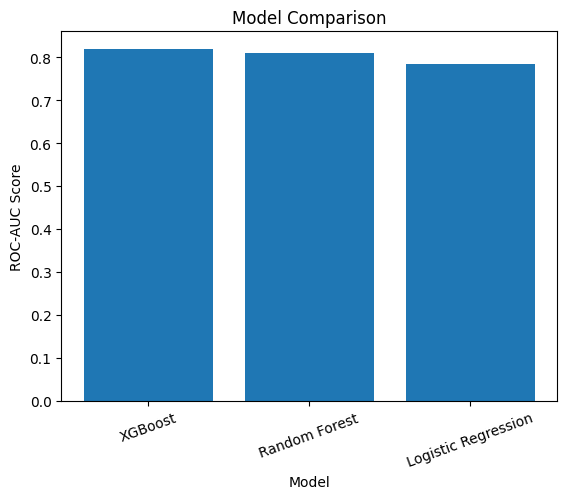

In [65]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(model_scores['Model'], model_scores['ROC-AUC'])

plt.xlabel("Model")
plt.ylabel("ROC-AUC Score")
plt.title("Model Comparison")

plt.xticks(rotation=20)

plt.show()

#### 16.11 Best Model Selection

In [66]:
best_model_name = model_scores.iloc[0]['Model']

print("Best Model:", best_model_name)

if best_model_name == 'XGBoost':
    best_model = xgb_model
elif best_model_name == 'Random Forest':
    best_model = rf_model
else:
    best_model = lr_model

Best Model: XGBoost


In [67]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top Features:\n")
print(importance_df.head(10))

Top Features:

              Feature  Importance
5   resolved_time_sec    0.232798
2         tenure_days    0.067403
13   company_sizing_8    0.065323
3      remaining_days    0.064672
8    company_sizing_3    0.063099
12   company_sizing_7    0.061648
0           total_bob    0.058777
10   company_sizing_5    0.057942
7    company_sizing_2    0.057768
1    service_interval    0.056221


## 17. MODEL EXPLAINABILITY

To ensure our churn prediction model is transparent and interpretable, we applied explainability techniques.

We used feature Importance to understand overall drivers of churn. SHAP (SHapley Additive exPlanations) to explain both global behavior and individual predictions.


#### Feature Importance

In [ ]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top Features:\n")
print(importance.head(10))

plt.figure(figsize=(8,5))
plt.barh(importance['Feature'], importance['Importance'])
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.grid()

plt.show()

## Optinal (for threshold tuning and new data)

In [60]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.1)

results = []

for t in thresholds:
    y_pred_t = (y_prob_xgb > t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    results.append([t, precision, recall, f1])

threshold_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])

print(threshold_df)

   Threshold  Precision    Recall        F1
0        0.1   0.389937  0.994652  0.560241
1        0.2   0.405192  0.959893  0.569841
2        0.3   0.424552  0.887701  0.574394
3        0.4   0.452342  0.748663  0.563948
4        0.5   0.469799  0.561497  0.511571
5        0.6   0.484496  0.334225  0.395570
6        0.7   0.525424  0.165775  0.252033
7        0.8   0.640000  0.042781  0.080201


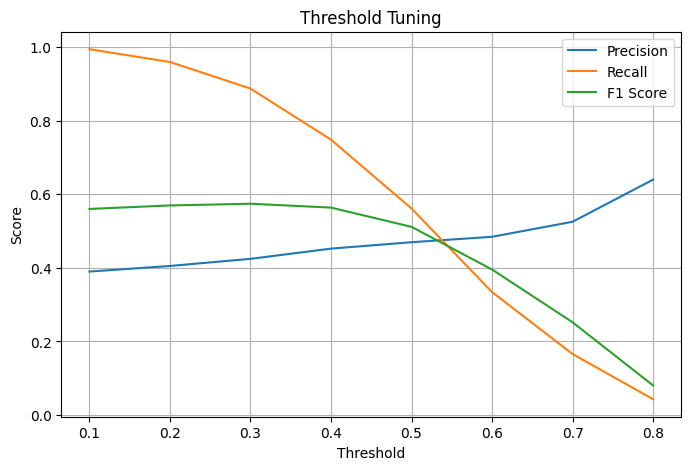

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(threshold_df['Threshold'], threshold_df['Precision'], label='Precision')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], label='Recall')
plt.plot(threshold_df['Threshold'], threshold_df['F1'], label='F1 Score')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.grid()

plt.show()

In [62]:
best_threshold = 0.4   # change based on your output

y_pred_final = (y_prob_xgb > best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.73      0.43      0.54       596
           1       0.45      0.75      0.56       374

    accuracy                           0.55       970
   macro avg       0.59      0.59      0.55       970
weighted avg       0.62      0.55      0.55       970

[[257 339]
 [ 94 280]]


In [63]:
new_data = pd.DataFrame({
    'company_sizing': ['20-49'],
    'total_bob': [5000],
    'service_interval': [10],
    'tenure_days': [1000],
    'remaining_days': [200],
    'near_expiry': [0],
    'agreement_count': [2]
})

new_data['company_sizing'] = new_data['company_sizing'].map({
    '1-9': 1, '10-19': 2, '20-49': 3, '50-99': 4,
    '100-249': 5, '250-499': 6, '500-999': 7, '>1000': 8
})
new_data[num_cols] = scaler.transform(new_data[num_cols])
prob = xgb_model.predict_proba(new_data)[:, 1]

threshold = 0.3
prediction = (prob > threshold).astype(int)

print("Churn Probability:", prob)
print("Prediction:", prediction)
if prediction == 1:
    if new_data['agreement_count'].iloc[0] > 1:
        print("Partial Churn")
    else:
        print("Full Churn")
else:
    print("No Churn")

Churn Probability: [0.12113004]
Prediction: [0]
No Churn


In [2]:
# Example validation
import pandas as pd
final_df['remaining_bucket'] = pd.cut(final_df['remaining_days'], bins=5)

final_df.groupby('remaining_bucket')['churn'].mean()

NameError: name 'final_df' is not defined